# Text-to-Image & Text-to-Speech Generation
**Author:** Md Atik Hasan  
**Platform:** Google Colab  

---

## 1️⃣ Check GPU
```python
!nvidia-smi



Checked GPU availability

Installed required libraries (diffusers, transformers, accelerate)

Loaded Stable Diffusion pipeline on GPU

Generated images from text prompts

Controlled generation with num_inference_steps

Created custom function to display single/multiple images

Generated speech from text using Hugging Face TT


#Text-to-image Generation using stable Diffusion and Diffusers

In [1]:
!nvidia-smi

Mon Jan 12 17:19:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#diffusers is a huggging face page for using diffusion models form huggingface hub
!pip install diffusers transformers accelerate


In [3]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
!pip show torch

Name: torch
Version: 2.9.0+cu126
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


#model select

In [5]:
model_id1 = "dreamlike-art/dreamlike-diffusion-1.0"

In [6]:
pipe = StableDiffusionPipeline.from_pretrained(
    model_id1,
    torch_dtype=torch.float16,
    use_safetensors=True, #cause gpu used

    )

pipe = pipe.to("cuda") #load gpu for first run

model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.72G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [7]:
#prompt
prompt = "a photograph of an astronaut riding a horse"


In [8]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

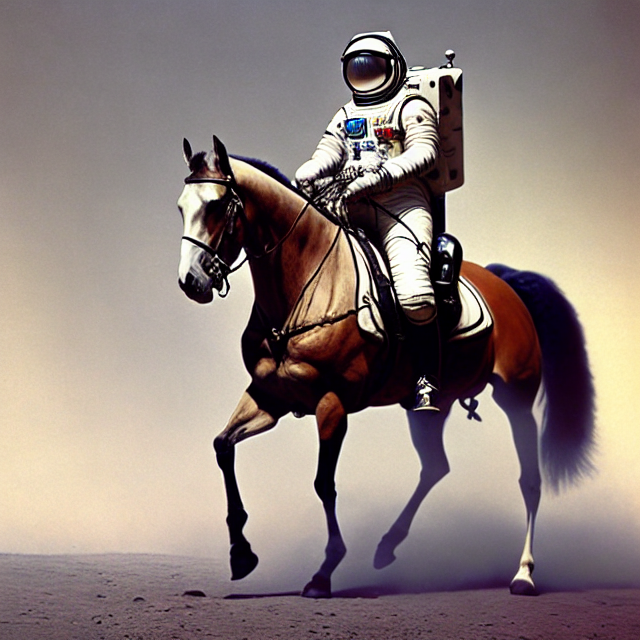

In [9]:
image

In [19]:

prompt ="A peaceful village pond full of clear water with fish swimming under the surface, reflections of trees in water, green leaves around, blue sky, highly detailed, ultra realistic, 4k"


In [22]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

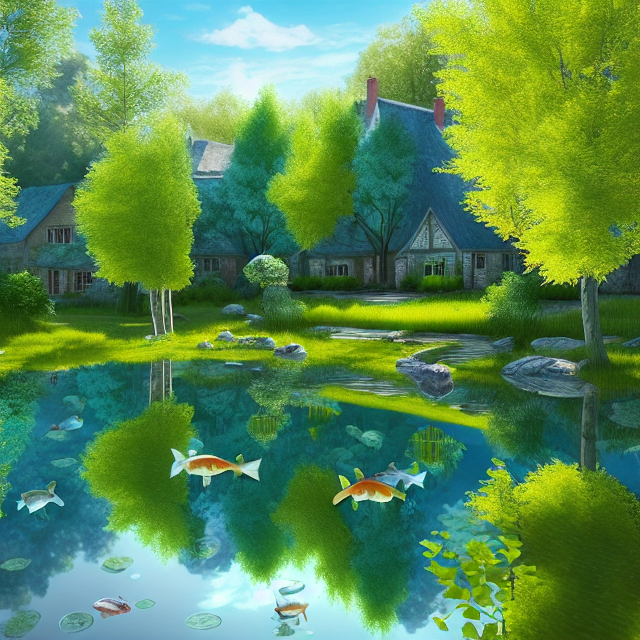

In [23]:
image

#working with stable Diffusion parameters

* Negative prompting
* Num_inference_steps
* height
* weight
* num_images_per_prompt


In [26]:
def generate_image(pipe, prompt, params):
  img = pipe(prompt, **params).images

  num_images = len(img)
  if num_images > 1:
    fig, ax = plt.subplots(nrows=1,ncols=num_images)
    for i in range(num_images):
      ax[i].imshow(img[i])
      ax[i].axis('off')
  else:
    fig = plt.figure()
    plt.imshow(img[0])
    plt.axis('off')
  plt.tight_layout()

In [27]:
prompt = "Cute girl character in anime style, colorful background, soft lighting, friendly expression, high detail illustration"

In [28]:
params = {}


  0%|          | 0/50 [00:00<?, ?it/s]

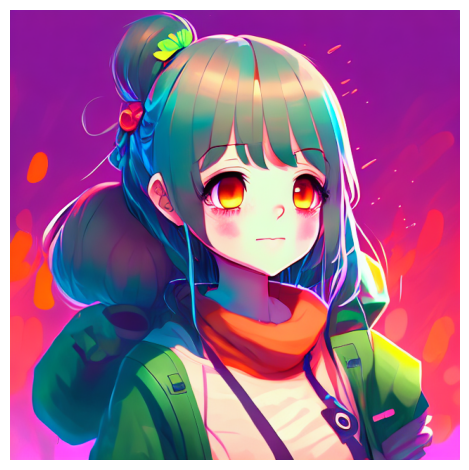

In [29]:
generate_image(pipe,prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

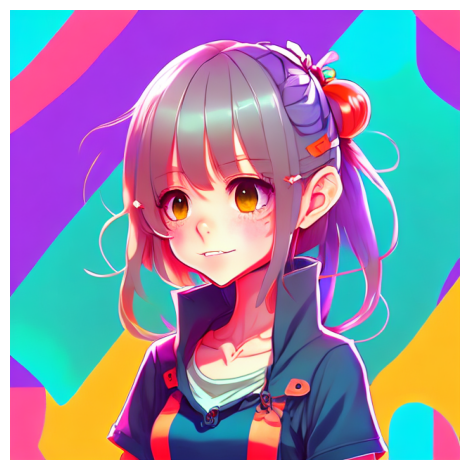

In [30]:
#num inference steps

params = {'num_inference_steps': 100}

generate_image(pipe, prompt, params)

#Text_to_speech_generation

In [32]:
from transformers import pipeline

In [48]:
text = "python is a high-level , general-purpose programming language."
pipe = pipeline("text-to-speech", model='suno/bark-small',device="cuda")


Device set to use cuda


In [49]:
output = pipe(text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.


In [50]:
output

{'audio': array([[ 0.00656846,  0.00274963,  0.0034357 , ..., -0.01909468,
         -0.01119382, -0.00883324]], dtype=float32),
 'sampling_rate': 24000}

In [51]:
from IPython.display import Audio
Audio(output['audio'], rate=output['sampling_rate'])